In [4]:
level_depth = 0

In [5]:
# CELL 1 — carica l’UNICO modello e prepara le variabili
from pathlib import Path
import pandas as pd, numpy as np, joblib
from sklearn.decomposition import LatentDirichletAllocation
from scipy.sparse import issparse

BASE = Path(f"/home/students/s328743/Thesis/Smart_crawler_telegram/results/levels/level_{level_depth}/grid_search_lda_optimized")
DF_SAMPLED = BASE / f"df_sampled_level_{level_depth}.csv"
GRID_CSV   = BASE / f"grid_search_results_level_{level_depth}.csv"
MODELS_DIR = BASE / f"lda_models_level_{level_depth}"
VECT_DIR   = BASE / f"vectorizers_level_{level_depth}"

df_sampled = pd.read_csv(DF_SAMPLED)
row = pd.read_csv(GRID_CSV).iloc[0]  # UNA sola riga

suffix = str(row.get("suffix") or "")

model_path = MODELS_DIR / f"{suffix}.joblib"
vectorizer_path = VECT_DIR / f"vectorizer_{suffix}.joblib"

lda_model = joblib.load(model_path)                       # scikit-learn LDA
vectorizer = joblib.load(vectorizer_path)                 # CountVectorizer
vocabulary = vectorizer.get_feature_names_out() if hasattr(vectorizer,"get_feature_names_out") else vectorizer.get_feature_names()
vocabulary = np.asarray(vocabulary)

X_counts = vectorizer.transform(df_sampled["text_preprocessed"].astype(str))
assert issparse(X_counts)
word_counts_vec = np.asarray(X_counts.sum(axis=0)).ravel().astype(int)

K, V = lda_model.components_.shape
print(f"K={K}, |V|={V}, model={model_path.name}")


K=58, |V|=3361, model=LDA_k58_ng1-1_minDF30_maxDF0.9_maxF50000_decay0.7.joblib


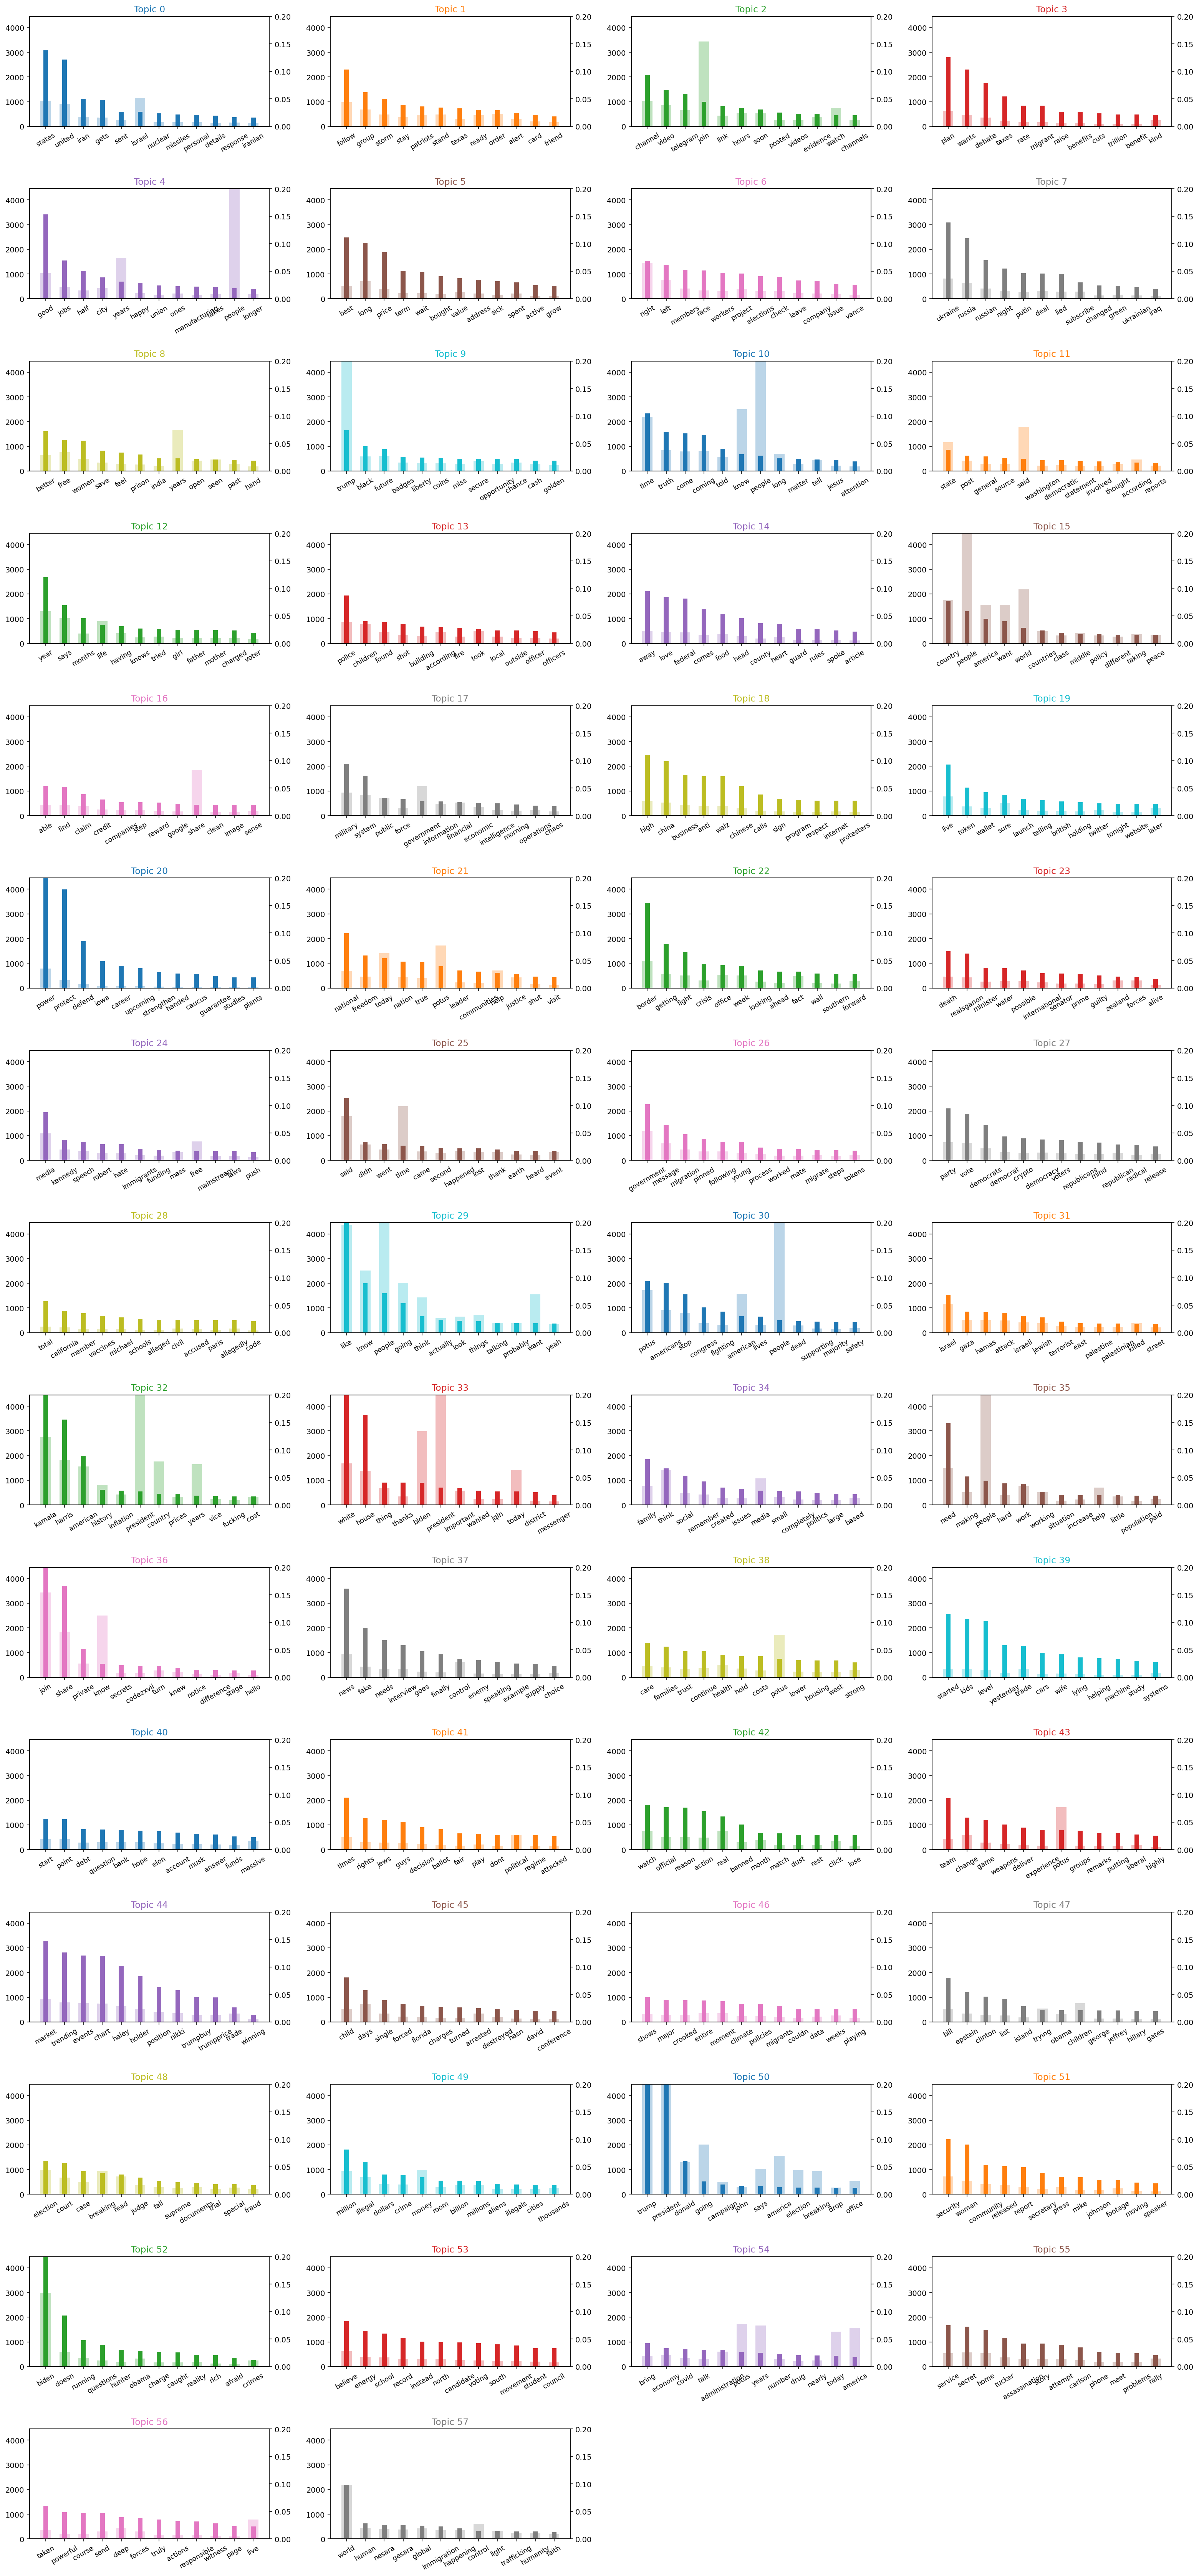

In [6]:
# CELL 2 — mostra top parole per topic (Word Count + Importance) in un unico grafico
import math, textwrap
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

TOPN = 12
W = lda_model.components_.astype(float)  # [K,V]

rows = []
for k in range(W.shape[0]):
    wk = W[k]; s = wk.sum() or 1.0
    probs = wk / s                       # ~ P(word|topic)
    idx = np.argsort(wk)[::-1][:TOPN]
    for j in idx:
        rows.append([vocabulary[j], k, probs[j], int(word_counts_vec[j])])

df_topics = pd.DataFrame(rows, columns=["word","topic_id","importance","word_count"])

n_topics = W.shape[0]
cols = 4 if n_topics >= 40 else (3 if n_topics >= 20 else 2)
rows_n = math.ceil(n_topics / cols)
fig, axes = plt.subplots(rows_n, cols, figsize=(cols*5.6, rows_n*3.2), dpi=140, squeeze=False)
palette = list(mcolors.TABLEAU_COLORS.values())

imp_max = float(np.percentile(df_topics['importance'], 99)) if len(df_topics) else 0.03
cnt_max = int(np.percentile(df_topics['word_count'], 99)) if len(df_topics) else 100
imp_max = max(0.03, round(imp_max, 3)); cnt_max = max(10, cnt_max)

for i in range(n_topics):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    di = df_topics[df_topics.topic_id == i].sort_values('importance', ascending=False)
    words = [textwrap.fill(w, 14) for w in di['word']]
    counts = di['word_count'].to_list()
    imps   = di['importance'].to_list()
    color  = palette[i % len(palette)]

    ax.bar(words, counts, color=color, alpha=0.30, width=0.55)
    ax.set_ylim(0, cnt_max)
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax2 = ax.twinx()
    ax2.bar(words, imps, color=color, width=0.25)
    ax2.set_ylim(0, imp_max)
    ax.set_title(f"Topic {i}", color=color, fontsize=12)

for j in range(n_topics, rows_n*cols):
    axes[j//cols][j%cols].axis('off')

fig.tight_layout(w_pad=2.0, h_pad=2.0)
plt.show()
